# EDA — Kaggle COVID-19 CBC

**Nguồn**: Kaggle `tawsifurrahman/covid19-complete-blood-count-clinical-database` — người dùng tự tải tay.

**File**: `Data/tabular/kaggle_covid_cbc/COVID-19_CBC_Data.csv` — 103 dòng × 14 cột, có nhãn `Outcome` (Recovered/Not Recovered).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
DATA = Path(r'D:\AI_08_V1\Data')

df = pd.read_csv(DATA / 'tabular' / 'kaggle_covid_cbc' / 'COVID-19_CBC_Data.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Missing values:', df.isna().sum().sum())
print('Dòng trùng lặp:', df.duplicated().sum())
df.head()

Shape: (103, 14)
Columns: ['Admission_DATE ', 'Discharge_DATE or date of Death', 'Outcome', 'Patient Age', 'Gender', 'Sample Collection Date ', 'What kind of Treatment provided ', 'Ventilated (Y/N)', 'Red blood cell distribution width', 'Monocytes(%)', 'White blood cell count', 'Platelet Count', 'Lymphocyte Count', 'Neutrophils Count']
Missing values: 0
Dòng trùng lặp: 0


,Admission_DATE,Discharge_DATE or date of Death,Outcome,Patient Age,Gender,Sample Collection Date,What kind of Treatment provided,Ventilated (Y/N),Red blood cell distribution width,Monocytes(%),White blood cell count,Platelet Count,Lymphocyte Count,Neutrophils Count
0,8/10/2020,8/8/2020,Not Recovered,51,Male,8/10/2020,"antibiotics, O2",Yes,13.2,3.3,21.00,462.00,0.44,19.43
1,7/24/2020,8/5/2020,Not Recovered,65,Female,7/24/2020,"Paracetamol, Antibiotics, O2",Yes,40.0,3.0,8.79,180.66,4.39,7.56
2,7/22/2020,8/8/2020,Recovered,32,Male,7/22/2020,"Antibiotics, O2",No,11.7,5.3,9.90,336.00,3.47,5.34
3,7/19/2020,8/5/2020,Recovered,36,Female,7/19/2020,"Antibiotics, O2",No,13.0,5.0,9.95,240.10,0.80,8.66
4,7/18/2020,8/5/2020,Recovered,46,Male,7/18/2020,"Paracetamol, Antibiotics, O2",No,31.0,3.0,14.15,236.58,7.93,13.02


Outcome
Recovered        61
Not Recovered    42
Name: count, dtype: int64
Outcome
Recovered        0.592
Not Recovered    0.408
Name: proportion, dtype: float64


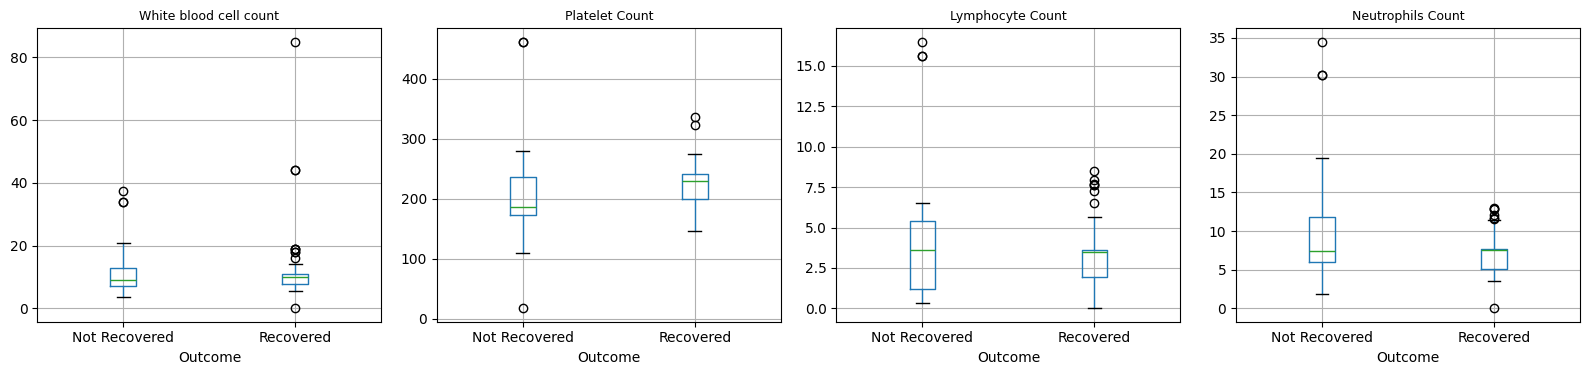

In [2]:
# Phân bố nhãn Outcome + so sánh chỉ số CBC theo Outcome
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True).round(3))

cbc_cols = ['White blood cell count', 'Platelet Count', 'Lymphocyte Count', 'Neutrophils Count']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cbc_cols):
    df.boxplot(column=col, by='Outcome', ax=ax)
    ax.set_title(col, fontsize=9)
plt.suptitle('')
plt.tight_layout()
plt.show()

## Nhận xét

- Không có missing value — hiếm gặp so với các bộ khác trong kho.
- Có nhãn `Outcome` thật (Recovered 61 / Not Recovered 42, tương đối cân bằng) — nhưng là outcome điều trị COVID-19, không phải chẩn đoán bệnh huyết học.
- Thiếu nhiều chỉ số CBC cốt lõi (không có RBC, Hgb, HCT, MCV, MCH, MCHC).
- Cỡ mẫu rất nhỏ (103 dòng) — chỉ phù hợp proof-of-concept, không đủ để train model đáng tin cậy.